### Импорт

In [20]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from PIL import UnidentifiedImageError
import random

### Загрузка данных и разбиение на тренировочную и тестовую выборки

In [13]:
data_dir = 'archive'  


In [15]:
train_path = os.path.join(data_dir, 'train')
test_path = os.path.join(data_dir, 'test')

# Проверка на существование директорий
if not os.path.exists(train_path) or not os.path.exists(test_path):
    raise FileNotFoundError("Проверьте, что директории 'train' и 'test' существуют в 'archive/'.")

# Параметры
img_size = (150, 150)
batch_size = 32
num_classes = 1  # Бинарная классификация

# Аугментация и нормализация
train_aug = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_aug = ImageDataGenerator(rescale=1.0 / 255)

# Генераторы изображений
train_gen = train_aug.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_gen = test_aug.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)


Found 3424 images belonging to 2 classes.
Found 840 images belonging to 2 classes.


### 3. Реализация полносвязной нейронной сети

In [16]:
# Модель
model = models.Sequential([
    layers.Flatten(input_shape=img_size + (3,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Для бинарной классификации
])

# Компиляция
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Обучение модели
history_dense = model.fit(
    train_gen,
    epochs=10,
    validation_data=test_gen,
)


d:\python3.12\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10


d:\python3.12\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


107/107 ━━━━━━━━━━━━━━━━━━━━ 43s 377ms/step - accuracy: 0.5329 - loss: 10.3222 - val_accuracy: 0.5810 - val_loss: 0.7196
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 39s 344ms/step - accuracy: 0.5943 - loss: 0.6950 - val_accuracy: 0.6226 - val_loss: 0.6383
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 39s 345ms/step - accuracy: 0.6171 - loss: 0.6871 - val_accuracy: 0.6095 - val_loss: 0.6665
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 38s 339ms/step - accuracy: 0.6268 - loss: 0.6517 - val_accuracy: 0.5917 - val_loss: 0.6762
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 38s 335ms/step - accuracy: 0.6211 - loss: 0.6634 - val_accuracy: 0.6083 - val_loss: 0.6649
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 38s 336ms/step - accuracy: 0.6195 - loss: 0.6661 - val_accuracy: 0.5964 - val_loss: 0.6726
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 38s 338ms/step - accuracy: 0.6220 - loss: 0.6611 - val_accuracy: 0.5964 - val_loss: 0.6746
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 38s 337ms/step - accuracy: 0.6323 - loss: 0.6548 - va

In [17]:
model.save('dense_model.keras')


### 4. Графики для полносвязной модели

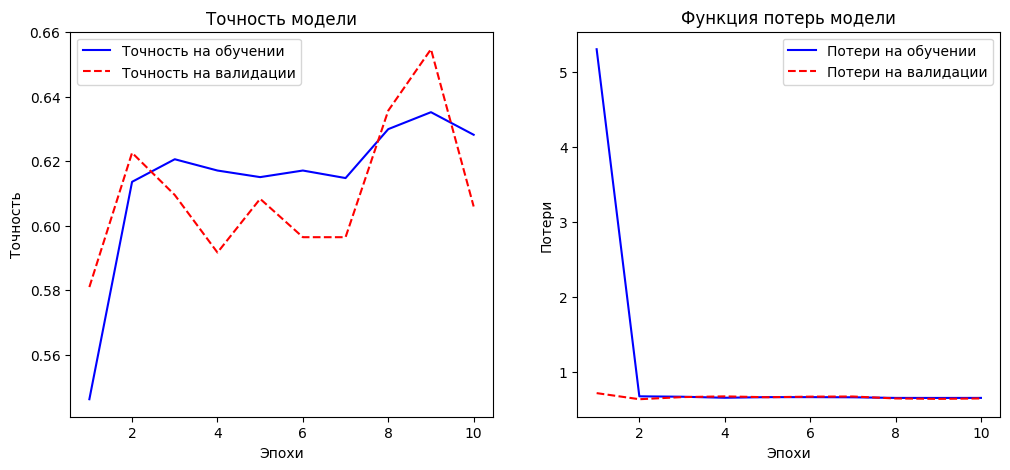

In [18]:
# Построение графиков accuracy и loss для модели

import matplotlib.pyplot as plt

# Данные из history
acc = history_dense.history['accuracy']
val_acc = history_dense.history['val_accuracy']
loss = history_dense.history['loss']
val_loss = history_dense.history['val_loss']

epochs = range(1, len(acc) + 1)

# График точности (accuracy)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Точность на обучении')
plt.plot(epochs, val_acc, 'r--', label='Точность на валидации')
plt.title('Точность модели')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

# График функции потерь (loss)
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Потери на обучении')
plt.plot(epochs, val_loss, 'r--', label='Потери на валидации')
plt.title('Функция потерь модели')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()

plt.show()


### 5. Реализация свёрточной нейронной сети

In [21]:
# Создание свёрточной модели

cnn_model = models.Sequential([
    Input(shape=(150, 150, 3)),  
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


# Компиляция модели
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Обучение модели
cnn_history = cnn_model.fit(
    train_gen,
    epochs=20,
    validation_data=test_gen,
)


Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 49s 427ms/step - accuracy: 0.6249 - loss: 0.7154 - val_accuracy: 0.8381 - val_loss: 0.3567
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 44s 397ms/step - accuracy: 0.8379 - loss: 0.3966 - val_accuracy: 0.8524 - val_loss: 0.3154
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 433ms/step - accuracy: 0.8613 - loss: 0.3374 - val_accuracy: 0.8845 - val_loss: 0.2663
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 410ms/step - accuracy: 0.8784 - loss: 0.2931 - val_accuracy: 0.9119 - val_loss: 0.2278
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 421ms/step - accuracy: 0.8750 - loss: 0.2910 - val_accuracy: 0.9190 - val_loss: 0.2129
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 45s 405ms/step - accuracy: 0.8898 - loss: 0.2510 - val_accuracy: 0.9202 - val_loss: 0.2115
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 413ms/step - accuracy: 0.9018 - loss: 0.2380 - val_accuracy: 0.9095 - val_loss: 0.2248
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 420ms/step - accuracy: 0.8966 - loss: 0

In [22]:
cnn_model.save('conv_model.keras')


### 6. Графики для свёрточной модели

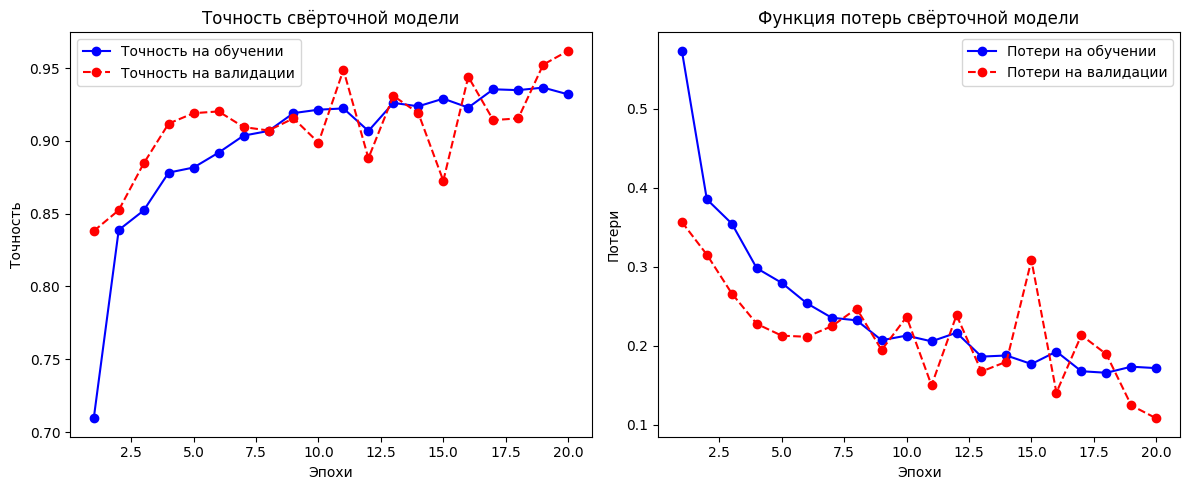

In [30]:
# Данные из истории обучения
acc = cnn_history['accuracy']
val_acc = cnn_history['val_accuracy']
loss = cnn_history['loss']
val_loss = cnn_history['val_loss']


epochs = range(1, len(acc) + 1)

# Построение графиков
plt.figure(figsize=(12, 5))

# График точности
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Точность на обучении')
plt.plot(epochs, val_acc, 'ro--', label='Точность на валидации')
plt.title('Точность свёрточной модели')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

# График потерь
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Потери на обучении')
plt.plot(epochs, val_loss, 'ro--', label='Потери на валидации')
plt.title('Функция потерь свёрточной модели')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()

plt.tight_layout()
plt.show()


### 7. Вывод результатов

In [31]:
# Оценка точности на тестовой выборке из генератора
dense_test_loss, dense_test_acc = model.evaluate(test_gen, verbose=0)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_gen, verbose=0)

# Округление точности до двух знаков
dense_acc_rounded = round(dense_test_acc, 2)
cnn_acc_rounded = round(cnn_test_acc, 2)

# Вывод результатов
print(f"Точность полносвязной модели: {dense_acc_rounded:.2f}")
print(f"Точность свёрточной модели: {cnn_acc_rounded:.2f}")

# Сравнение моделей
if dense_acc_rounded > cnn_acc_rounded:
    print("Полносвязная нейронная сеть показала лучшую точность.")
elif cnn_acc_rounded > dense_acc_rounded:
    print("Свёрточная нейронная сеть показала лучшую точность.")
else:
    print("Обе модели показали одинаковую точность.")


Точность полносвязной модели: 0.61
Точность свёрточной модели: 0.96
Свёрточная нейронная сеть показала лучшую точность.


### 8. Демонстрация классификации изображений

Предсказания полносвязной модели (Dense):


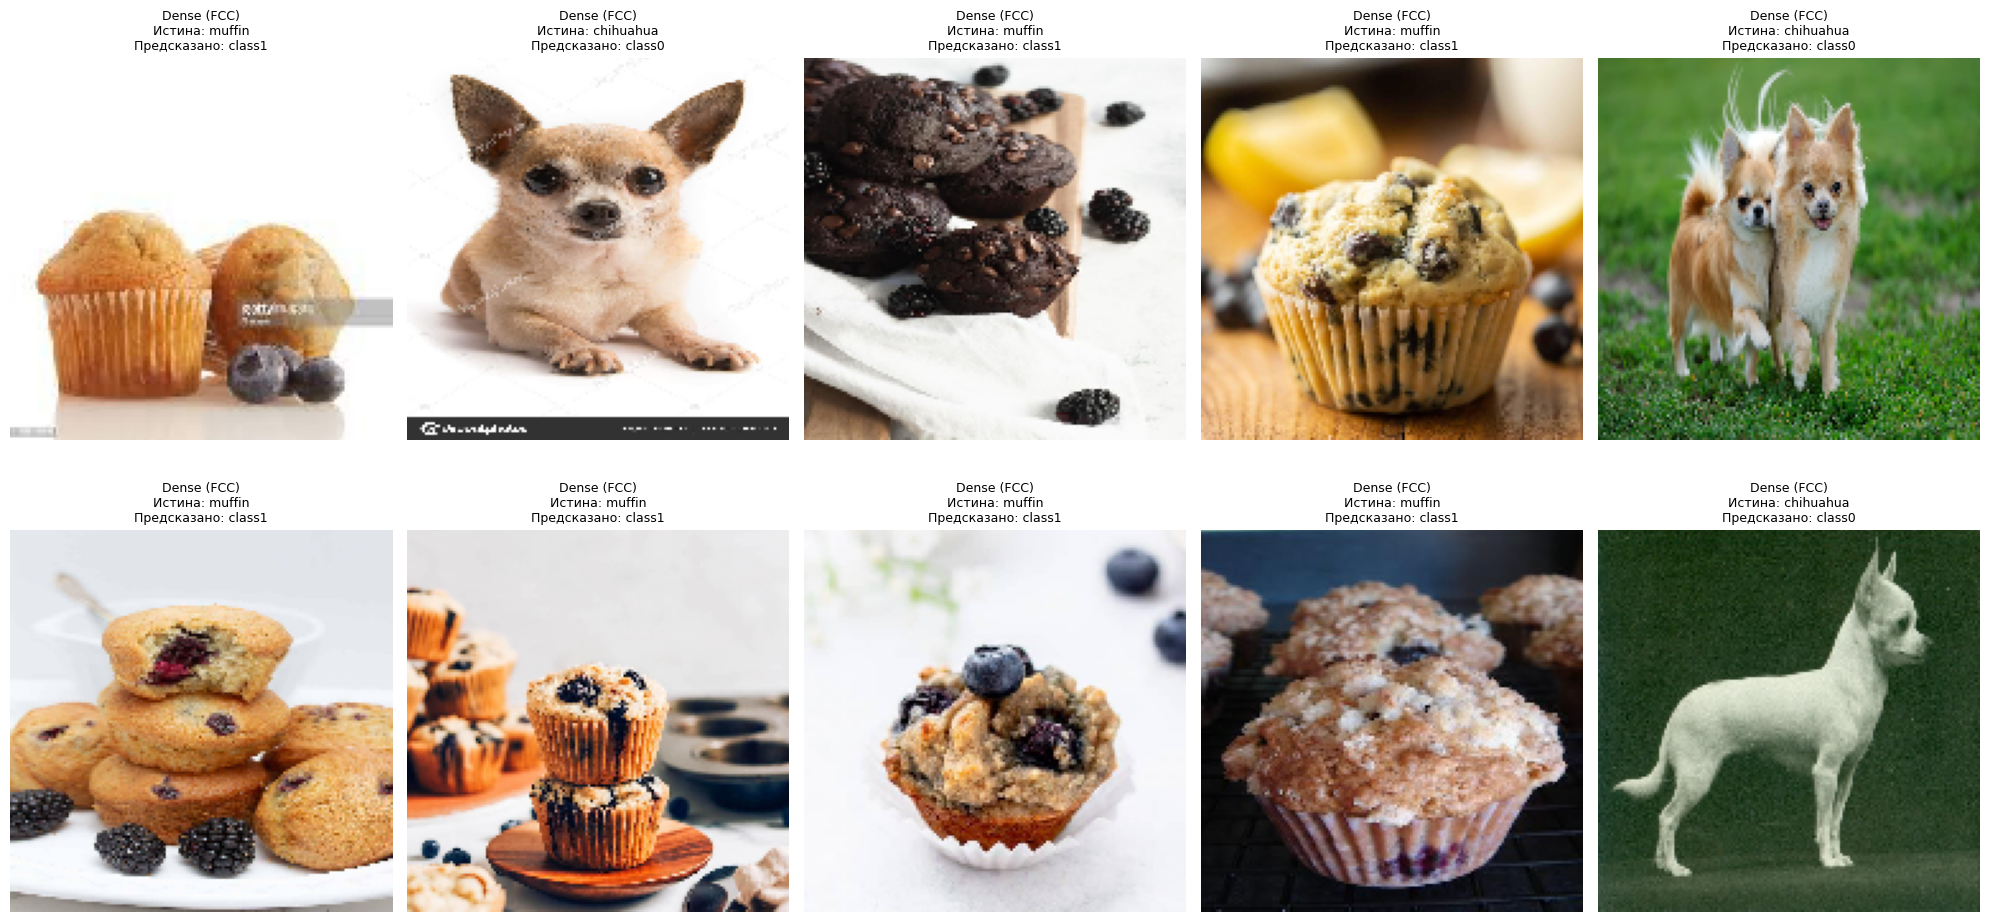

Предсказания свёрточной модели (CNN):


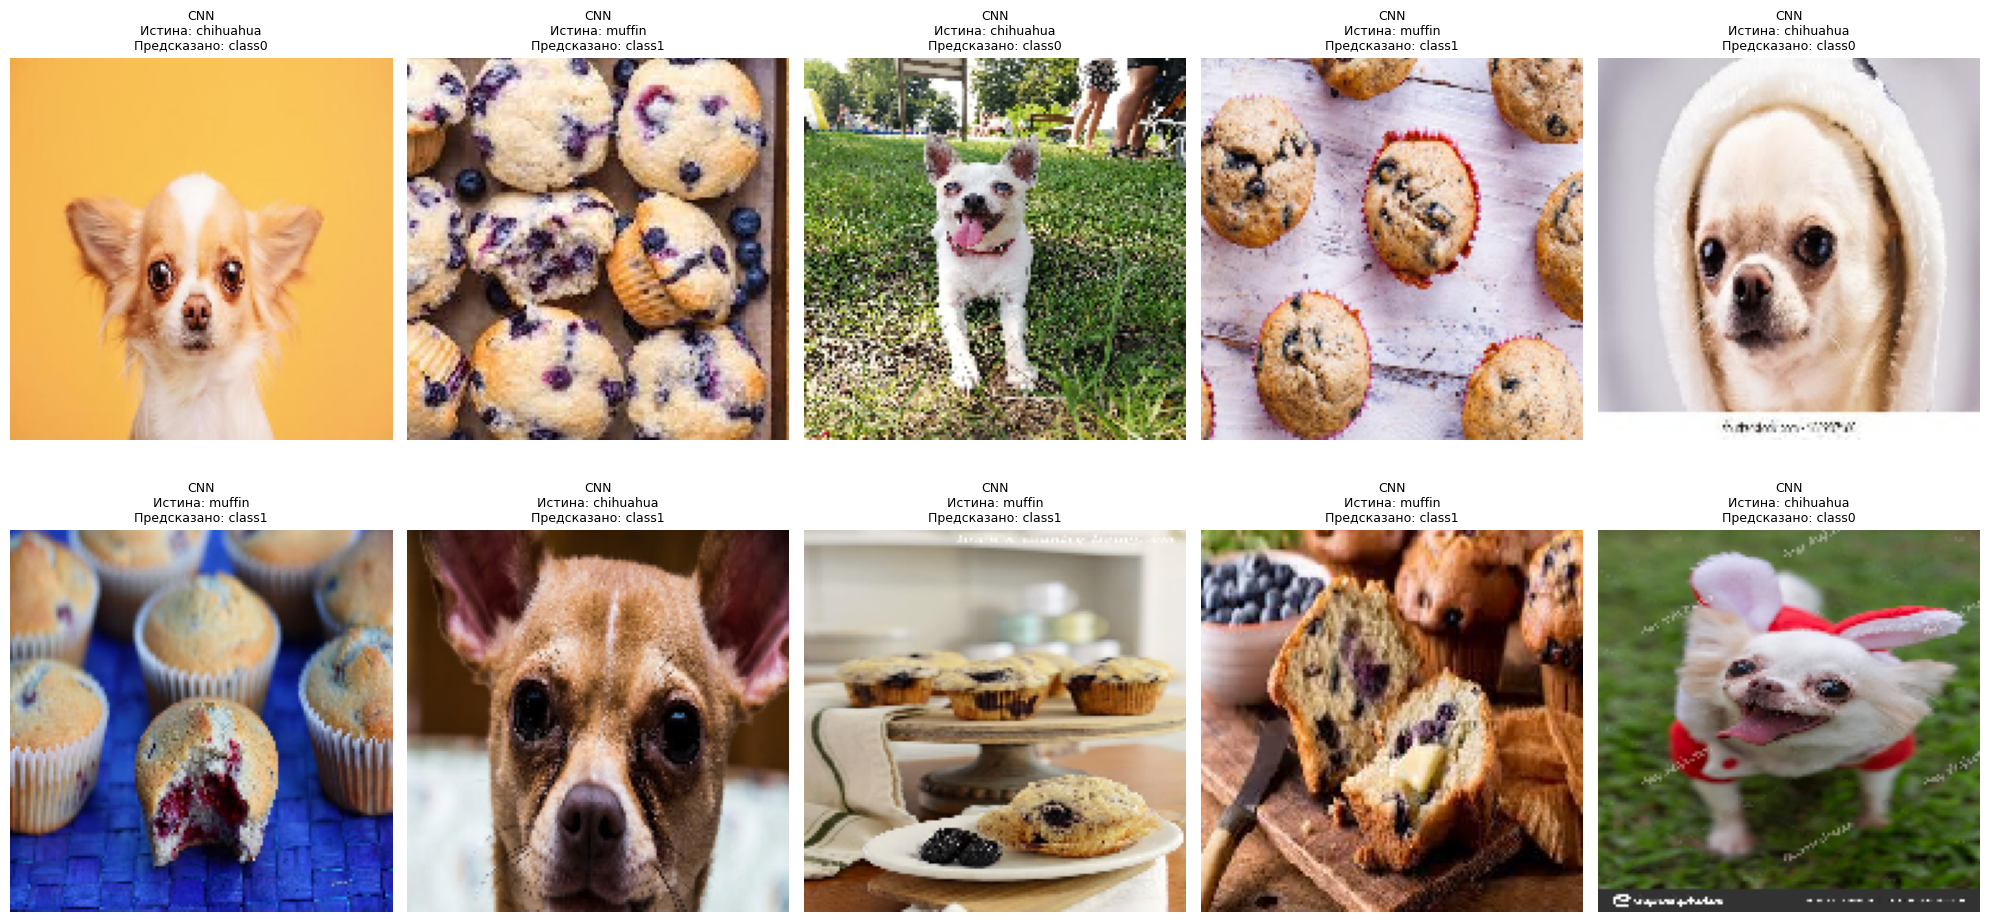

In [32]:
test_dir = 'archive/test'
categories = [d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))]

# Загрузка моделей
model_fcc = load_model('dense_model.h5')
model_conv = load_model('conv_model.h5')

def get_random_images(num_images=10):
    all_images = []
    for category in categories:
        folder = os.path.join(test_dir, category)
        images = [os.path.join(folder, f) for f in os.listdir(folder)
                  if f.lower().endswith(('jpg', 'jpeg', 'png'))]
        all_images.extend(images)
    random.shuffle(all_images)
    return all_images[:num_images]


def show_predictions(image_paths, model, model_name):
    plt.figure(figsize=(20, 10))
    for idx, img_path in enumerate(image_paths):
        img = load_img(img_path, target_size=(150, 150))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array, verbose=0)[0][0]
        predicted_label = "class1" if prediction >= 0.5 else "class0"
        true_label = os.path.basename(os.path.dirname(img_path))

        plt.subplot(2, 5, idx + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{model_name}\nИстина: {true_label}\nПредсказано: {predicted_label}", fontsize=9)
    plt.tight_layout()
    plt.show()

fcc_images = get_random_images(10)
print("Предсказания полносвязной модели (Dense):")
show_predictions(fcc_images, model_fcc, "Dense (FCC)")

conv_images = get_random_images(10)
print("Предсказания свёрточной модели (CNN):")
show_predictions(conv_images, model_conv, "CNN")



**Вывод**
Полносвязная модель достигла точности 0.61, тогда как свёрточная нейронная сеть показала значительно более высокую точность — 0.96. Это свидетельствует о заметном преимуществе CNN в распознавании визуальных паттернов по сравнению с Dense-архитектурой. Тем не менее, несмотря на явный разрыв в метриках, оба подхода могут быть ограничены текущими условиями эксперимента. Возможно, модели не достигли полного потенциала из-за недостаточного количества обучающих данных или ограниченного разнообразия примеров. Это также может указывать на необходимость доработки архитектур для более эффективного извлечения признаков. Для дальнейшего улучшения качества классификации можно расширить и разнообразить обучающий датасет, протестировать более глубокие и специализированные архитектуры CNN.